In [ ]:
!pip install google-play-scraper

# mengimpor pustaka google play_play_scraper untuk mengakses ulasan dan informasi aplikasi dari google play store
from google_play_scraper import app, reviews, Sort, reviews_all

import pandas as pd # panda untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None # menonaktifkan peringatan chaining
import numpy as np # numpy untuk komputasi numerik
seed = 0
np.random.seed(seed) # mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt # matplotlib untuk visualisasi data
import seaborn as sns # seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt # manipulasi data waktu dan tanggal
import re # modul untuk bekerja dengan ekspresi reguler
import string # berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize # tokenisasi teks
from nltk.corpus import stopwords # daftar kata kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory # Stemming (penghilang imbuhan kata) dalam bahasa indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory # menghapus kata kata berhenti dalam bahasa indonesia

from wordcloud import WordCloud # membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk # import pustaka nltk (natural language toolkit)
nltk.download('punkt') # mengunduh dataset yang diperlukan untuk tokenisasi teks
nltk.download('stopwords') # mengunduh dataset yang berisi daftar kata kata berhenti (stopwords dalam berbagai bahasa)
nltk.download('punkt_tab')




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# mengimpor pustaka google_play_scraper untuk mengakses ulasan dan informasi aplikasi dari google play store
from google_play_scraper import app, reviews_all, Sort

# mengambil semua ulasan dari aplikasi dengan id 'ovo.id' di google play store
# proses scraping mungkin memerlukan beberapa saat tergantung pada jumlah ulasan yang ada
scrapreview = reviews_all(
    'ovo.id',                 # id aplikasi
    lang='id',                # bahasa ulasan (default: 'en')
    country='id',             # negara (default: 'us')
    sort=Sort.MOST_RELEVANT,  # urutan ulasan (default: Sort.MOST_RELEVANT)
    count=300                # jumlah maksimum ulasan yang ingin diambil
)


In [ ]:
# menyimpan ulasan dalam file csv
import csv

with open ('ulasan_aplikasi.csv', mode='w', newline='', encoding='utf-8') as file:
  writer = csv.writer(file)
  writer.writerow(['Review']) # menulis header kolom
  for review in scrapreview:
    writer.writerow([review['content']]) # menulis konten ulasan ke dalam file csv

In [ ]:
app_reviews_df = pd.DataFrame(scrapreview)
app_reviews_df.shape
app_reviews_df.head()
app_reviews_df.to_csv('ulasan_aplikasi.csv', index=False)

# membuat dataframe dari hasil scrapview
app_reviews_df = pd.DataFrame(scrapreview)

# menghitung jumlah baris dan kolom dalam dataframe
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [ ]:
# menampilkan lima baris pertama dalam dataframe app_reviews_df

app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,b24a0639-4977-4124-a887-9f9ddd8978fd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Hati-hati jangan simpen uang banyak di apk ini...,1,1451,3.149.0,2025-12-16 07:28:52,None,NaT,3.149.0
1,39386497-5dd1-498f-88e9-a756d4744aee,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"fitur ubah nomor gak guna, karena nomor lama h...",1,557,3.150.0,2026-01-10 14:38:15,None,NaT,3.150.0
2,734d1fa7-72d8-4f72-ad56-90dd193af814,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Cara penggunaan yg ribet.. untuk harga.. Token...,1,245,3.150.0,2025-12-31 02:08:21,"Hai Kak, maaf ya. Terkait dengan kendala yang ...",2024-08-12 05:19:01,3.150.0
3,c9ccdd5c-7ce9-4512-a789-5c917bfa8983,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sebenarnya aplikasi ini bagus, tapi karena bia...",3,14,3.153.0,2026-02-07 01:55:26,None,NaT,3.153.0
4,ef4f5fb4-0933-4614-a984-16d526ba7cad,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi aneh scan qr buat pembayarannya saldo...,1,41,3.150.0,2026-01-12 20:38:09,None,NaT,3.150.0


In [ ]:
# menampilkan informasi tentang dataframe app_reviews_df
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265500 entries, 0 to 265499
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              265500 non-null  object        
 1   userName              265500 non-null  object        
 2   userImage             265500 non-null  object        
 3   content               265499 non-null  object        
 4   score                 265500 non-null  int64         
 5   thumbsUpCount         265500 non-null  int64         
 6   reviewCreatedVersion  210503 non-null  object        
 7   at                    265500 non-null  datetime64[ns]
 8   replyContent          138557 non-null  object        
 9   repliedAt             138557 non-null  datetime64[ns]
 10  appVersion            210503 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 22.3+ MB


In [ ]:
# membuat dataframe baru (clean_df) dengan menghapus baris yang memiliki nilai yang hilang (NaN) dari app_reviews_df
clean_df = app_reviews_df.dropna()

In [ ]:
# menghapus baris duplikat dari dataframe clean_df
clean_df = clean_df.drop_duplicates()

# menghapus jumlah baris dan kolom dalam dataframe clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

# menampilkan informasi tentang dataframe clean_df setelah membersihkan nilai yang hilang (Nan)
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106821 entries, 2 to 265201
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              106821 non-null  object        
 1   userName              106821 non-null  object        
 2   userImage             106821 non-null  object        
 3   content               106821 non-null  object        
 4   score                 106821 non-null  int64         
 5   thumbsUpCount         106821 non-null  int64         
 6   reviewCreatedVersion  106821 non-null  object        
 7   at                    106821 non-null  datetime64[ns]
 8   replyContent          106821 non-null  object        
 9   repliedAt             106821 non-null  datetime64[ns]
 10  appVersion            106821 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 9.8+ MB


In [ ]:
def cleaningText(text):
  text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
  text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
  text = re.sub(r'RT[\s]', '', text) # menghapus RT
  text = re.sub(r"http\S+", '', text) # menghapus link
  text = re.sub(r'[0-9]+', '', text) # menghapus angka
  text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

  text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
  text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
  text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
  return text

def casefoldingText(text): # mengubah semua karakter dalam teks menjadi huruf kecil
  text = text.lower()
  return text

def tokenizingText(text): # memecah atau membagi string, teks menjadi daftar token
  text = word_tokenize(text)
  return text

def filteringText(text): # menghapus stopwords dalam teks
  listStopwords = set(stopwords.words('indonesian'))
  listStopwords1 = set(stopwords.words('english'))
  listStopwords.update(listStopwords1)
  listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
  filtered = []
  for txt in text:
    if txt not in listStopwords:
      filtered.append(txt)
  text = filtered
  return text

def stemmingText(text): # mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
  # membuat objek stemmer
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()

  # memecah teks menjadi daftar kata
  words = text.split()

  # menerapkan stemming pada setiap kata dalam daftar
  stemmed_words = [stemmer.stem(word) for word in words]

  # menggabungkan kata-kata yang telah distem
  stemmed_text = ' '.join(stemmed_words)

  return stemmed_text

def toSentence(list_words): # mengubah daftar kata menjadi kalimat
  sentence = ' '.join(word for word in list_words)
  return sentence


In [ ]:
slangwords = {
    "@": "di",
    "abis": "habis",
    "wtb": "beli",
    "masi": "masih",
    "wts": "jual",
    "wtt": "tukar",
    "bgt": "banget",
    "mks": "maksimal",

    # ========== TAMBAHAN SLANGWORDS ==========
    # Negasi / penyangkalan
    "ga": "tidak", "gak": "tidak", "gaa": "tidak", "nggak": "tidak",
    "ngga": "tidak", "kaga": "tidak", "kagak": "tidak", "tdk": "tidak",
    "gk": "tidak", "ngk": "tidak", "ndak": "tidak", "tak": "tidak",
    "tida": "tidak", "tidad": "tidak", "tidack": "tidak",

    # Kata ganti orang
    "sy": "saya", "gw": "saya", "gue": "saya", "aku": "saya",
    "lu": "kamu", "lo": "kamu", "loe": "kamu", "kau": "kamu",
    "km": "kamu", "mu": "kamu", "ur": "kamu",
    "dia": "dia", "dy": "dia", "dya": "dia",
    "kita": "kita", "kit": "kita", "kt": "kita",
    "kami": "kami", "kmi": "kami",

    # Kata hubung / partikel
    "aj": "aja", "aja": "saja", "doank": "doang", "doang": "saja",
    "jg": "juga", "jga": "juga", "jua": "juga", "juge": "juga",
    "sja": "saja", "sj": "saja", "sz": "saja",
    "lah": "lah", "kah": "kah", "pun": "pun",

    # Kata keterangan waktu
    "udh": "sudah", "udah": "sudah", "sdh": "sudah", "sda": "sudah",
    "blm": "belum", "blom": "belum", "bim": "belum",
    "skrg": "sekarang", "skg": "sekarang", "sekarang": "sekarang",
    "kmrn": "kemarin", "kmaren": "kemarin", "kemrn": "kemarin",
    "besok": "besok", "bsk": "besok", "esok": "besok",
    "nnti": "nanti", "nti": "nanti", "nant": "nanti",

    # Kata tanya
    "gmn": "gimana", "gimana": "bagaimana", "bgmn": "bagaimana",
    "dmn": "dimana", "dimn": "dimana",
    "knp": "kenapa", "kenp": "kenapa", "knapa": "kenapa",
    "kpn": "kapan", "kpan": "kapan", "kapn": "kapan",
    "apa": "apa", "ap": "apa", "ape": "apa",
    "siapa": "siapa", "spa": "siapa", "sapa": "siapa",

    # Kata depan
    "krn": "karena", "krena": "karena", "karn": "karena", "karene": "karena",
    "utk": "untuk", "untk": "untuk", "buat": "untuk", "bwt": "untuk",
    "dri": "dari", "dr": "dari", "drpd": "daripada",
    "pd": "pada", "pda": "pada", "d": "di",
    "ke": "ke", "k": "ke", "dlm": "dalam", "dlam": "dalam",
    "sma": "sama", "sama": "sama", "dgn": "dengan", "dng": "dengan",

    # Kata kerja / sifat
    "msh": "masih", "msi": "masih", "mas": "masih",
    "blh": "boleh", "bole": "boleh",
    "bs": "bisa", "bsa": "bisa", "bias": "bisa",
    "mau": "mau", "mw": "mau", "mo": "mau",
    "pke": "pakai", "pake": "pakai", "make": "pakai",
    "krg": "kurang", "krng": "kurang", "min": "kurang",
    "byk": "banyak", "bnyk": "banyak",
    "sdh": "sedia", "sdia": "sedia",
    "trs": "terus", "terus": "terus", "trus": "terus",
    "jd": "jadi", "jdi": "jadi", "jdy": "jadi",

    # Lain-lain
    "yg": "yang", "yng": "yang", "yag": "yang", "iang": "yang",
    "orng": "orang", "org": "orang", "urang": "orang",
    "tp": "tapi", "tpi": "tapi", "tapii": "tapi", "tap": "tapi",
    "kr": "kali", "kli": "kali", "kl": "kali",
    "yah": "ya", "yaa": "ya", "iya": "iya",
    "oh": "oh", "wah": "wah", "ah": "ah", "eh": "eh",
    "dong": "dong", "donk": "dong", "dunk": "dong",
    "kok": "kok", "kox": "kok", "kook": "kok",
    "deh": "deh", "dah": "deh", "ajg": "deh"
}
def fix_slangwords(text):
  words = text.split()
  fixed_words = []

  for word in words:
    if word.lower() in slangwords:
      fixed_words.append(slangwords[word.lower()])
    else:
      fixed_words.append(word)

  fixed_text = ' '.join(fixed_words)
  return fixed_text


In [ ]:
# membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# mengubah huruf dalam text menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# mengganti kata kata slang dengan kata kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# memecah teks menjadi token (kata kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# menghapus kata kata stop (kata kata umum) dan menyimpannya di 'text_stopwords'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# menggabungkan token token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)


In [ ]:
import csv
import requests
from io import StringIO

# membaca data kamus kata kata positif dari github
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# mengirim permintaan HTTP untuk mendapatkan file CSV dari github

if response.status_code == 200:
  # jika permintaan berhasil
  reader = csv.reader(StringIO(response.text), delimiter=',')
  # membaca teks respons sebagai file csv menggunakan pembaca csv dengan pemisah koma

  for row in reader:
    # mengulangi setiap baris dalam file csv
    lexicon_positive[row[0]] = int(row[1])
    # menambahkan kata kata positif dan skornya ke dalam kamus lexicon_positive

else:
  print("Failed to fetch positive lexicon data")

# membaca data kamus kata kata negatif dari github
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# mengirim permintaan HTTP untuk mendapatkan file csv dari github

if response.status_code == 200:
  # jika permintaan berhasil
  reader = csv.reader(StringIO(response.text), delimiter=',')
  # membaca teks respons sebagai file csv menggunakan pembaca csv dengan pemisah koma

  for row in reader:
    # mengulangi setiap baris dalam file csv
    lexicon_negative[row[0]] = int(row[1])
    # menambahkan kata kata negatif dan skornya dalam kamus lexicon_negative

else:
  print("Failed to fetch negative lexicon data")







In [ ]:
# fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
  # for word in text:

  score = 0
  # inisialisasi skor sentimen ke 0

  for word in text:
    # mengulangi setiap kata dalam teks

    if (word in lexicon_positive):
      score = score + lexicon_positive[word]
      # jika ada kata dalam kamus positive, tambahkan skornya ke skor sentimen

  for word in text:
    # mengulangi setiap kata dalam teks (sekali lagi)

    if (word in lexicon_negative):
      score = score + lexicon_negative[word]
      # jika kata ada dalam kamus negative, kurangkan skornya dari skor sentimen

  polarity = ''
  # inisialisasi variabel polaritas

  if (score > 0):
    polarity = 'positive'
    # jika skor sentimen lebih besar dari 0, maka polaritas adalah positive
  elif (score < 0):
    polarity = 'negative'
    # jika skor sentimen kurang dari 0, maka polaritas adalah negative
  else:
    polarity = 'neutral'
    # jika skor sentimen sama dengan 0, maka polaritas adalah neutral

  return score, polarity
  # mengembalikan skor sentimen dan polaritas teks

In [ ]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    56523
positive    32970
neutral     17328
Name: count, dtype: int64


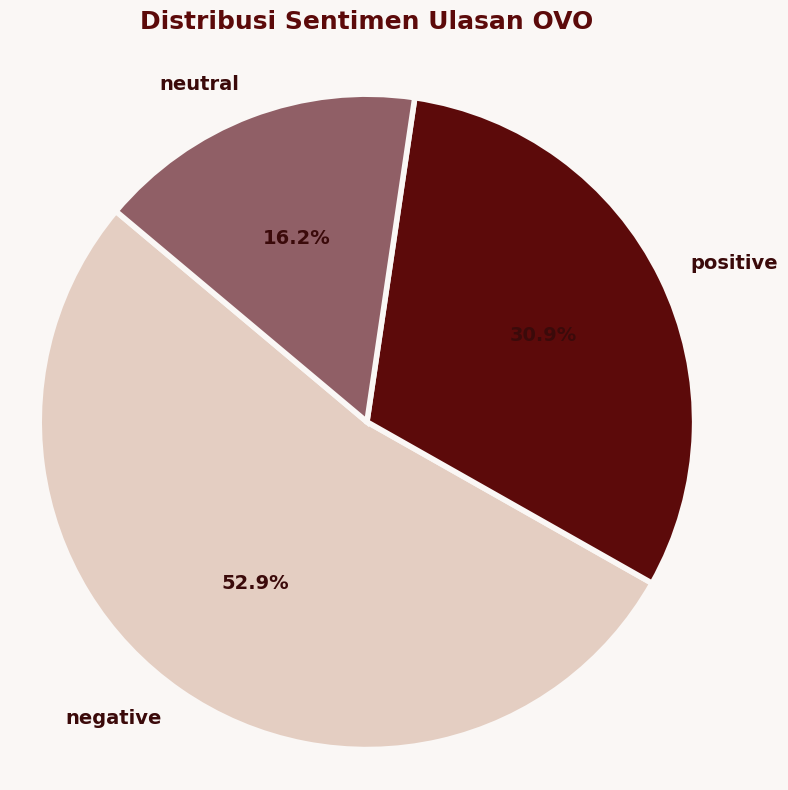

In [ ]:
import matplotlib.pyplot as plt

# Palette warna aesthetic
wine_maroon = "#5C0A0A"      # untuk positive
soft_nude = "#E4CEC2"        # untuk negative
neutral_gray = "#905F66"     # untuk neutral (aesthetic grayish mauve)

sentiment_counts = clean_df['polarity'].value_counts()

color_map = {
    'positive': wine_maroon,
    'negative': soft_nude,
    'neutral': neutral_gray
}

colors = [color_map[label] for label in sentiment_counts.index]

plt.figure(figsize=(8,8), facecolor='#FAF7F5')

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={
        'edgecolor': '#FAF7F5',
        'linewidth': 4
    },
    textprops={
        'fontsize':14,
        'fontweight':'bold',
        'color':'#3B0A0A'
    }
)

plt.title(
    "Distribusi Sentimen Ulasan OVO",
    fontsize=18,
    fontweight='bold',
    color=wine_maroon,
    pad=25
)

plt.axis('equal')
plt.tight_layout()
plt.show()

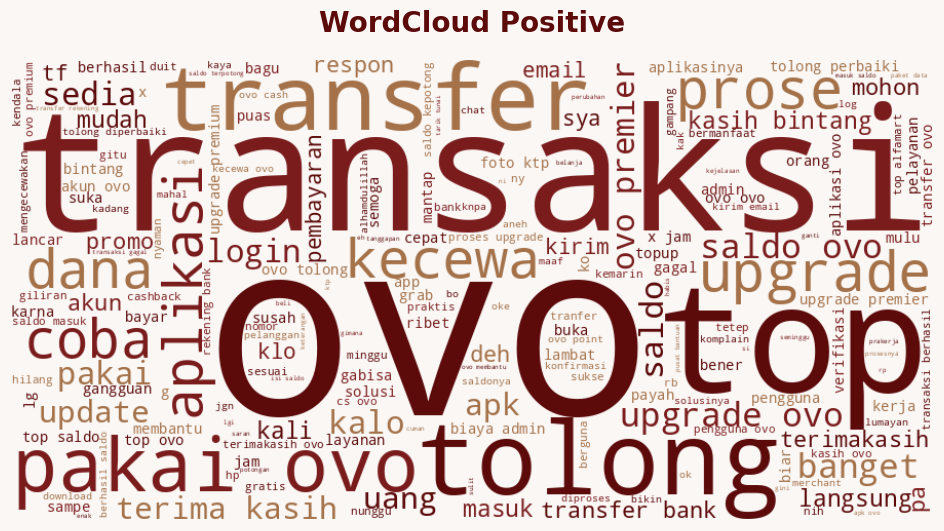

In [ ]:
import random
positive_palette = ["#5C0A0A", "#7A1C1C", "#A47148"]

def positive_color_func(*args, **kwargs):
    return random.choice(positive_palette)

positive_text = ' '.join(clean_df[clean_df['polarity']=='positive']['text_akhir'])

wc_positive = WordCloud(
    width=900,
    height=450,
    background_color="#FAF7F5",
    color_func=positive_color_func
).generate(positive_text)

plt.figure(figsize=(12,6), facecolor="#FAF7F5")
plt.imshow(wc_positive, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Positive", fontsize=20, fontweight="bold", color="#5C0A0A", pad=20)
plt.show()


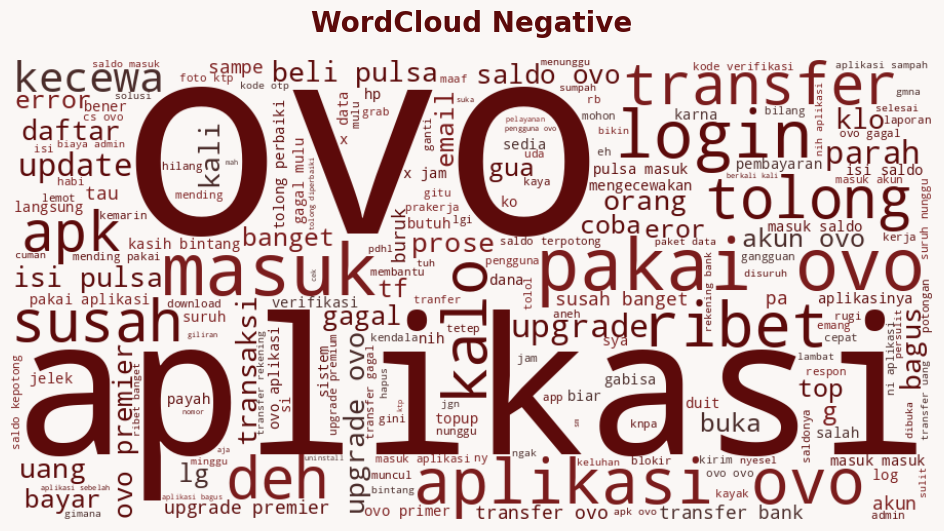

In [ ]:
import random

negative_palette = ["#5C0A0A", "#7A1C1C", "#4A2C2A"]

def negative_color_func(*args, **kwargs):
    return random.choices(
        negative_palette,
        weights=[0.45, 0.40, 0.15]  # burgundy lebih dominan
    )[0]

negative_text = ' '.join(clean_df[clean_df['polarity']=='negative']['text_akhir'])

wc_negative = WordCloud(
    width=900,
    height=450,
    background_color="#FAF7F5",
    color_func=negative_color_func
).generate(negative_text)

plt.figure(figsize=(12,6), facecolor="#FAF7F5")
plt.imshow(wc_negative, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Negative", fontsize=20, fontweight="bold", color="#5C0A0A", pad=20)
plt.show()


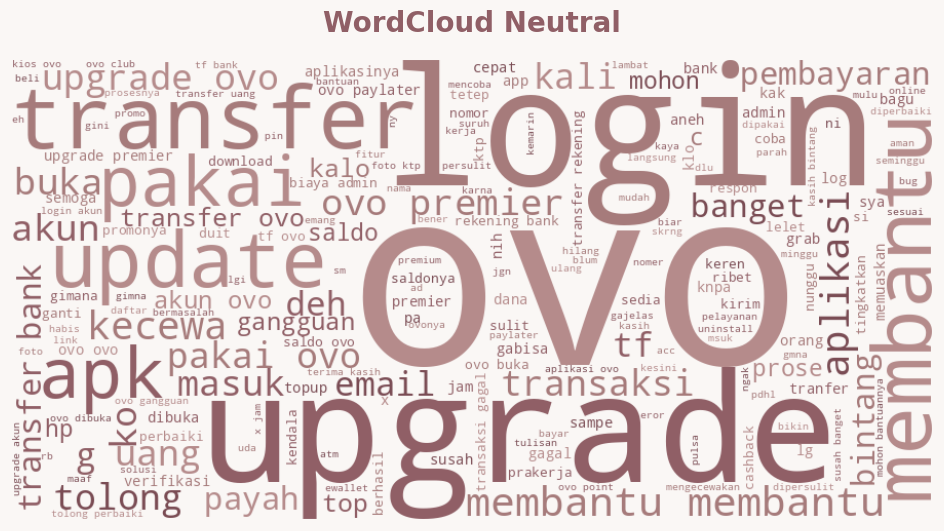

In [ ]:
import random
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Palette warna mauve aesthetic untuk neutral
neutral_palette = ["#905F66", "#A67B7B", "#B58B8B", "#7A4C54"]

def neutral_color_func(*args, **kwargs):
    return random.choices(
        neutral_palette,
        weights=[0.4, 0.25, 0.2, 0.15]  # dominan #905F66
    )[0]

neutral_text = ' '.join(clean_df[clean_df['polarity']=='neutral']['text_akhir'])

wc_neutral = WordCloud(
    width=900,
    height=450,
    background_color="#FAF7F5",
    color_func=neutral_color_func,
    colormap=None
).generate(neutral_text)

plt.figure(figsize=(12,6), facecolor="#FAF7F5")
plt.imshow(wc_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Neutral", fontsize=20, fontweight="bold", color="#905F66", pad=20)
plt.show()

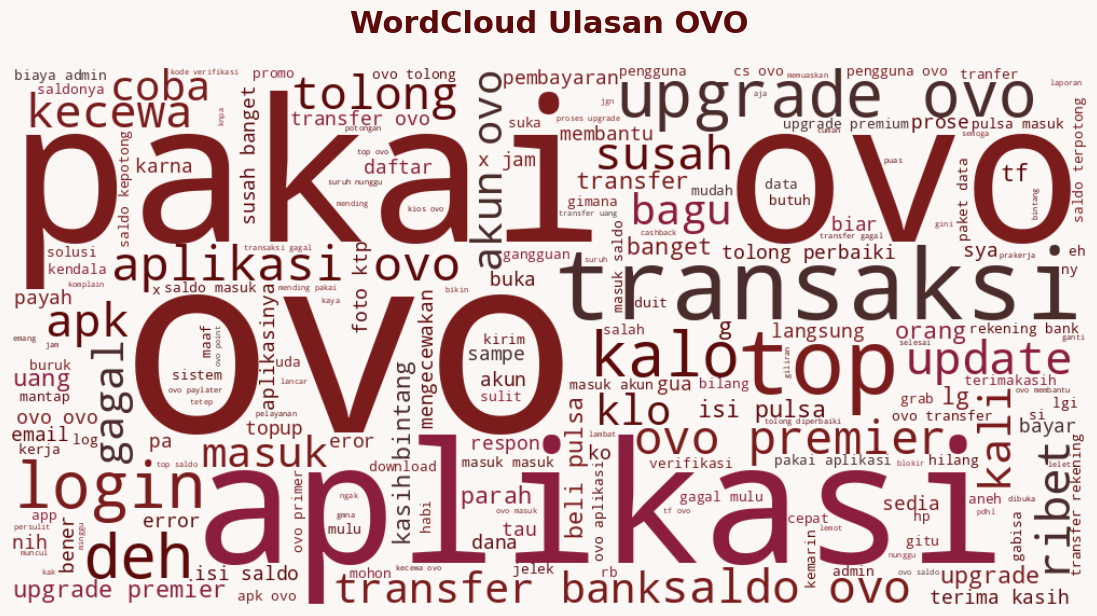

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import random

general_palette = ["#5C0A0A", "#7A1C1C", "#8B1E3F", "#4A2C2A"]

def general_color_func(*args, **kwargs):
    return random.choices(
        general_palette,
        weights=[0.4, 0.3, 0.2, 0.1]  # dominan burgundy
    )[0]

general_text = ' '.join(clean_df['text_akhir'])

wc_general = WordCloud(
    width=1000,
    height=500,
    background_color="#FAF7F5",
    color_func=general_color_func
).generate(general_text)

plt.figure(figsize=(14,7), facecolor="#FAF7F5")
plt.imshow(wc_general, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Ulasan OVO", fontsize=22, fontweight="bold", color="#5C0A0A", pad=25)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow_hub as hub
import tensorflow as tf
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.preprocessing import LabelEncoder

# 1. ELMo EMBEDDINGS gantiin tf idf
X = clean_df['text_akhir'].values
y = clean_df['polarity'].values

# Encode label ke angka
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

elmo = hub.load("https://tfhub.dev/google/elmo/3")

def get_elmo_embeddings(texts, batch_size=32):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size].tolist()
        batch_embeddings = elmo.signatures['default'](tf.constant(batch))['elmo']
        batch_mean = tf.reduce_mean(batch_embeddings, axis=1).numpy()
        embeddings.extend(batch_mean)
        print(f"Processed {min(i+batch_size, len(texts))}/{len(texts)}")
    return np.array(embeddings)

X_elmo = get_elmo_embeddings(X)
print(f"Shape ELMo embeddings: {X_elmo.shape}")

# smote
print("Sebelum SMOTE:", Counter(y_encoded))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_elmo, y_encoded)

print("Sesudah SMOTE:", Counter(y_resampled))
print(f"Shape X setelah SMOTE: {X_resampled.shape}")

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {Counter(y_train)}")
print(f"y_test distribution: {Counter(y_test)}")

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Processed 32/106821
Processed 64/106821
Processed 96/106821
Processed 128/106821
Processed 160/106821
Processed 192/106821
Processed 224/106821
Processed 256/106821
Processed 288/106821
Processed 320/106821
Processed 352/106821
Processed 384/106821
Processed 416/106821
Processed 448/106821
Processed 480/106821
Processed 512/106821
Processed 544/106821
Processed 576/106821
Processed 608/106821
Processed 640/106821
Processed 672/106821
Processed 704/106821
Processed 736/106821
Processed 768/106821
Processed 800/106821
Processed 832/106821
Processed 864/106821
Processed 896/106821
Processed 928/106821
Processed 960/106821
Processed 992/106821
Processed 1024/106821
Processed 1056/106821
Processed 1088/106821
Processed 1120/106821
Processed 1152/106821
Processed 1184/106821
Processed 1216/106821
Processed 1248/106821
Processed 1280/106821
Processed 1312/106821
Processed 1344/106821
Processed 1376/10682

y_train_cat shape: (135655, 3)
y_test_cat shape: (33914, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 1, 1024)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 598,787 (2.28 MB)

 Trainable params: 598,787 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
3392/3392 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - accuracy: 0.4733 - loss: 1.2390 - val_accuracy: 0.5152 - val_loss: 0.9866 - learning_rate: 0.0010
Epoch 2/30
3392/3392 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.5068 - loss: 0.9953 - val_accuracy: 0.5360 - val_loss: 0.9611 - learning_rate: 0.0010
Epoch 3/30
3392/3392 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.5326 - loss: 0.9807 - val_accuracy: 0.6321 - val_loss: 0.8971 - learning_rate: 0.0010
Epoch 4/30
3392/3392 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.6132 - loss: 0.9251 - val_accuracy: 0.6721 - val_loss: 0.8316 - learning_rate: 0.0010
Epoch 5/30
3392/3392 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.6401 - loss: 0.8934 - val_accuracy: 0.6845 - val_loss: 0.8089 - learning_rate: 0.0010
Epoch 6/30
3392/3392 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.6473 - loss: 0.8798 - val_accuracy: 0.6636 - val_loss: 0.8390 - learning_rate: 0.0010
Epoch 7/30
3392/3392 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - accuracy: 0.6

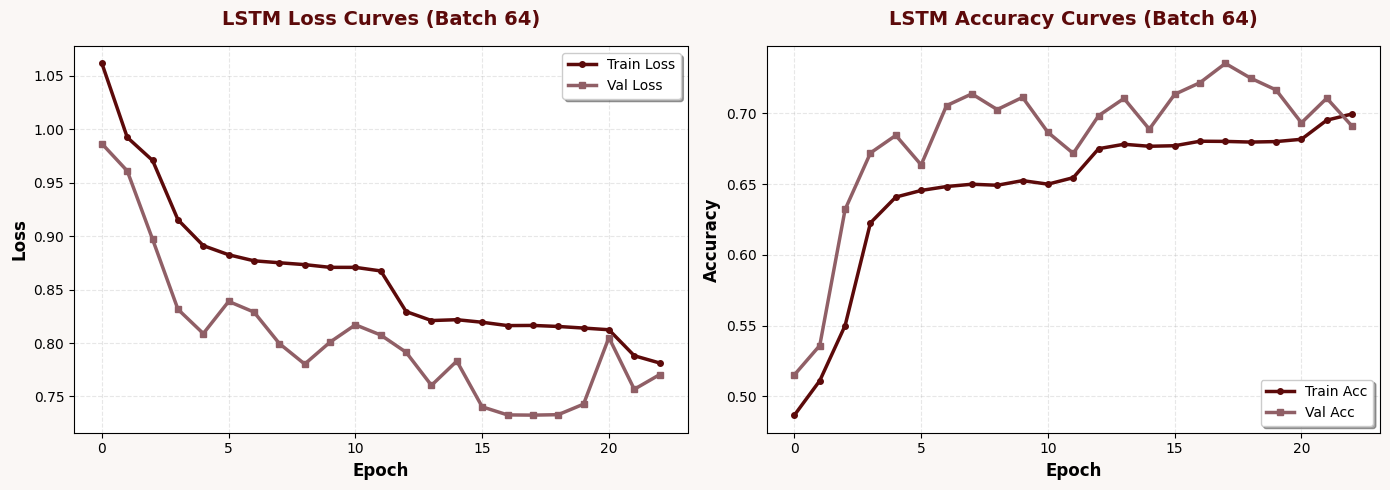

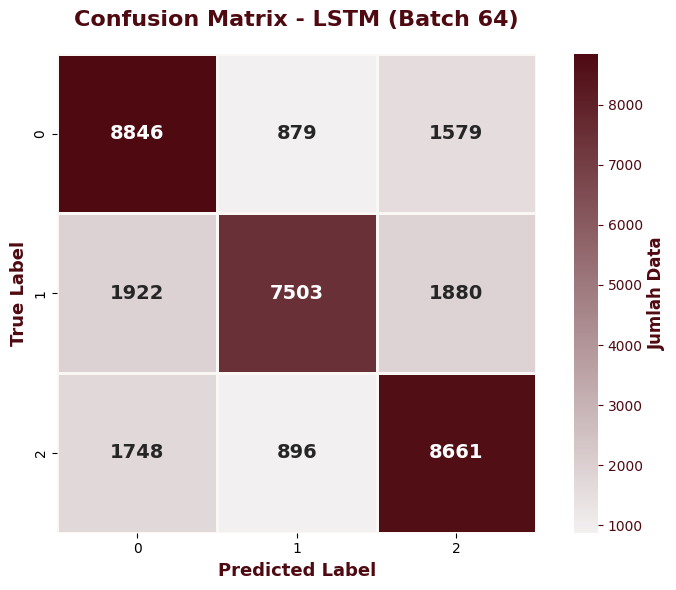

LSTM CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.71      0.78      0.74     11304
     neutral       0.81      0.66      0.73     11305
    positive       0.71      0.77      0.74     11305

    accuracy                           0.74     33914
   macro avg       0.74      0.74      0.74     33914
weighted avg       0.74      0.74      0.74     33914



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Reshape
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

# ============================================
# ONE HOT ENCODING
# ============================================
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)
print(f"y_train_cat shape: {y_train_cat.shape}")
print(f"y_test_cat shape: {y_test_cat.shape}")

# ============================================
# OPTIMIZER dengan Gradient Clipping
# ============================================
optimizer_adam = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

# ============================================
# CALLBACKS
# ============================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# ============================================
# MODEL LSTM
# ============================================
start_time = time.time()

model_lstm = Sequential([
    Input(shape=(X_train.shape[1],)),
    Reshape((1, X_train.shape[1])),

    # LSTM layer dengan L2 regularization
    LSTM(128,
         return_sequences=False,
         kernel_regularizer=l2(0.005),
         recurrent_regularizer=l2(0.005)),
    Dropout(0.35),

    Dense(64,
          activation='relu',
          kernel_regularizer=l2(0.005)),
    Dropout(0.35),

    Dense(3, activation='softmax')
])

model_lstm.compile(
    optimizer=optimizer_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

# ============================================
# TRAINING
# ============================================
history_lstm = model_lstm.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

end_time = time.time()
training_time_lstm = end_time - start_time

# ============================================
# EVALUASI
# ============================================
# Train evaluation
loss_lstm_train, acc_lstm_train = model_lstm.evaluate(X_train, y_train_cat, verbose=0)

# Test evaluation
loss_lstm_test, acc_lstm_test = model_lstm.evaluate(X_test, y_test_cat, verbose=0)

print(f"Train Accuracy:     {acc_lstm_train:.4f}")
print(f"Train Loss:         {loss_lstm_train:.4f}")
print(f"Test Accuracy:      {acc_lstm_test:.4f}")
print(f"Test Loss:          {loss_lstm_test:.4f}")
print(f"Accuracy Gap:       {abs(acc_lstm_train - acc_lstm_test):.4f}")
print(f"Training Time:      {training_time_lstm:.2f} seconds")
print(f"Epochs Completed:   {len(history_lstm.history['loss'])}")

# Overfitting check
gap_lstm = abs(acc_lstm_train - acc_lstm_test)
if gap_lstm > 0.10:
    print("WARNING: Potential overfitting detected!")
    print("Consider: Increase dropout to 0.4-0.5")
elif gap_lstm < 0.05:
    print("Excellent generalization!")
else:
    print("Good! Acceptable generalization gap")

print("="*70)

# ============================================
# VISUALISASI TRAINING CURVES
# ============================================
maroon_dark = "#5C0A0A"
maroon_light = "#905F66"
cream = "#FAF7F5"

plt.figure(figsize=(14, 5), facecolor=cream)

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'],
         label='Train Loss',
         color=maroon_dark,
         linewidth=2.5,
         marker='o',
         markersize=4)
plt.plot(history_lstm.history['val_loss'],
         label='Val Loss',
         color=maroon_light,
         linewidth=2.5,
         marker='s',
         markersize=4)
plt.title('LSTM Loss Curves (Batch 64)',
          fontsize=14,
          fontweight='bold',
          color=maroon_dark,
          pad=15)
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'],
         label='Train Acc',
         color=maroon_dark,
         linewidth=2.5,
         marker='o',
         markersize=4)
plt.plot(history_lstm.history['val_accuracy'],
         label='Val Acc',
         color=maroon_light,
         linewidth=2.5,
         marker='s',
         markersize=4)
plt.title('LSTM Accuracy Curves (Batch 64)',
          fontsize=14,
          fontweight='bold',
          color=maroon_dark,
          pad=15)
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ============================================
# CONFUSION MATRIX
# ============================================
y_pred_lstm = model_lstm.predict(X_test, verbose=0)
y_pred_classes_lstm = np.argmax(y_pred_lstm, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Palette warna maroon aesthetic
maroon_primary = "#4E0911"
maroon_light = "#640D14"
maroon_soft = "#7A1C1C"

cm_lstm = confusion_matrix(y_true_classes, y_pred_classes_lstm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm,
            annot=True,
            fmt='d',
            cmap=sns.light_palette(maroon_primary, as_cmap=True),
            cbar_kws={'label': 'Jumlah Data'},
            linewidths=2,
            linecolor=cream,
            square=True,
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('Confusion Matrix - LSTM (Batch 64)',
          fontsize=16,
          fontweight='bold',
          color=maroon_primary,
          pad=20)

# Label classes
class_names = label_encoder.classes_
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold', color=maroon_primary)
plt.ylabel('True Label', fontsize=13, fontweight='bold', color=maroon_primary)

# Customize colorbar
cbar = plt.gca().collections[0].colorbar
cbar.set_label('Jumlah Data', fontsize=12, fontweight='bold', color=maroon_primary)
cbar.ax.yaxis.set_tick_params(color=maroon_primary)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=maroon_primary)

plt.tight_layout()
plt.show()

# ============================================
# CLASSIFICATION REPORT
# ============================================
print("LSTM CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true_classes,
                          y_pred_classes_lstm,
                          target_names=class_names,
                          zero_division=0))
print("="*70)

y_train shape: (135655, 3)
y_test shape : (33914, 3)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2048)      │  2,099,200 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 2048)      │  4,196,352 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2048)      │          0 │ dropout_4[0][0],  │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1024)      │  2,098,176 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1024)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 512)       │    524,800 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │    131,328 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 3)         │        771 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,073,155 (34.61 MB)

 Trainable params: 9,061,891 (34.57 MB)

 Non-trainable params: 11,264 (44.00 KB)

Epoch 1/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.5717 - loss: 0.9847 - val_accuracy: 0.6915 - val_loss: 0.7087 - learning_rate: 5.0000e-04
Epoch 2/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7125 - loss: 0.6836 - val_accuracy: 0.7273 - val_loss: 0.6371 - learning_rate: 5.0000e-04
Epoch 3/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7328 - loss: 0.6436 - val_accuracy: 0.6948 - val_loss: 0.7117 - learning_rate: 5.0000e-04
Epoch 4/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7418 - loss: 0.6239 - val_accuracy: 0.6986 - val_loss: 0.7201 - learning_rate: 5.0000e-04
Epoch 5/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7465 - loss: 0.6084 - val_accuracy: 0.7569 - val_loss: 0.5782 - learning_rate: 5.0000e-04
Epoch 6/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7495 - loss: 0.6068 - val_accuracy: 0.7372 - val_loss: 0.6096 - learning_rate: 5.0000e-04
Epoch 7/60
848/848 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy

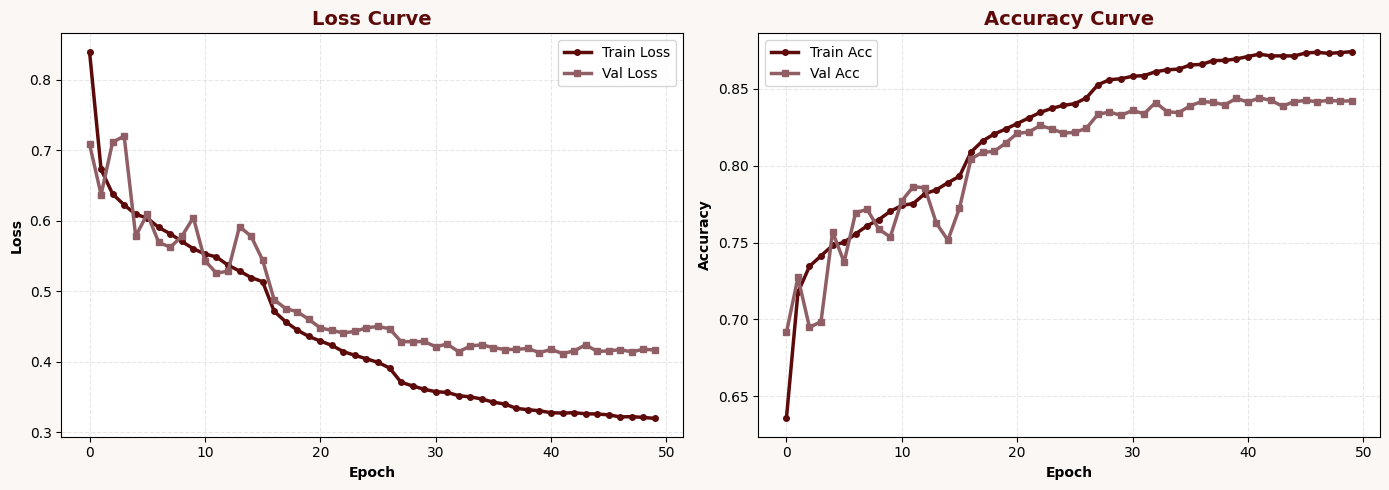

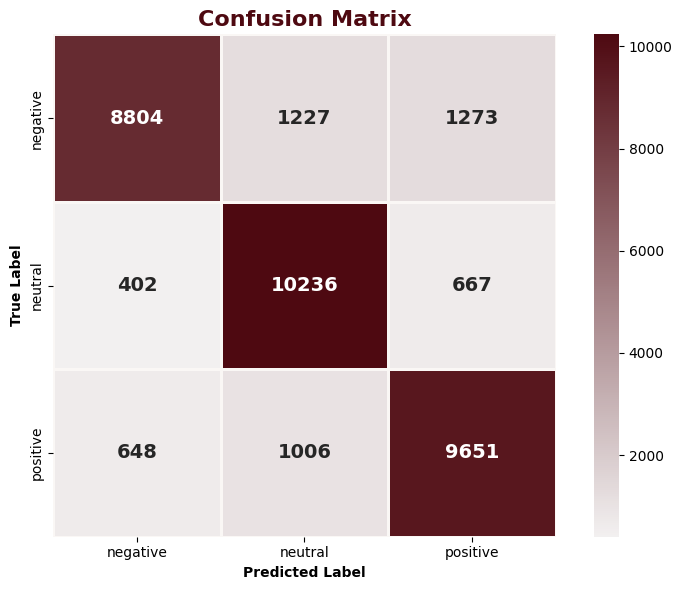

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.89      0.78      0.83     11304
     neutral       0.82      0.91      0.86     11305
    positive       0.83      0.85      0.84     11305

    accuracy                           0.85     33914
   macro avg       0.85      0.85      0.85     33914
weighted avg       0.85      0.85      0.85     33914



In [ ]:
# ============================================
# IMPORT
# ============================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import tensorflow as tf

# ============================================
# ONE HOT ENCODING
# ============================================
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print("y_train shape:", y_train_cat.shape)
print("y_test shape :", y_test_cat.shape)

# ============================================
# MODEL
# ============================================
input_layer = Input(shape=(X_train.shape[1],))

x = Dense(2048, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

# Residual Block
res1 = Dense(2048, activation='relu')(x)
res1 = BatchNormalization()(res1)
res1 = Dropout(0.3)(res1)
x = Add()([x, res1])

x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.25)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)

output = Dense(3, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================
# CALLBACKS
# ============================================
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

# ============================================
# TRAINING
# ============================================
start_time = time.time()

history = model.fit(
    X_train,
    y_train_cat,
    epochs=60,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

training_time = time.time() - start_time

# ============================================
# EVALUATION
# ============================================
train_loss, train_acc = model.evaluate(X_train, y_train_cat, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

gap = abs(train_acc - test_acc)

print(f"\nTrain Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Accuracy Gap   : {gap:.4f}")
print(f"Training Time  : {training_time:.2f} sec")
print(f"Epochs Run     : {len(history.history['loss'])}")

if gap > 0.10:
    print("WARNING: Model kemungkinan overfitting")
elif gap < 0.05:
    print("Excellent generalization!")
else:
    print("Good generalization.")

print("="*70)

# ============================================
# VISUALISASI TRAINING CURVES (MAROON THEME)
# ============================================
maroon_dark = "#5C0A0A"
maroon_light = "#905F66"
cream = "#FAF7F5"

plt.figure(figsize=(14,5), facecolor=cream)

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'],
         label='Train Loss',
         color=maroon_dark,
         linewidth=2.5,
         marker='o',
         markersize=4)

plt.plot(history.history['val_loss'],
         label='Val Loss',
         color=maroon_light,
         linewidth=2.5,
         marker='s',
         markersize=4)

plt.title('Loss Curve',
          fontsize=14,
          fontweight='bold',
          color=maroon_dark)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],
         label='Train Acc',
         color=maroon_dark,
         linewidth=2.5,
         marker='o',
         markersize=4)

plt.plot(history.history['val_accuracy'],
         label='Val Acc',
         color=maroon_light,
         linewidth=2.5,
         marker='s',
         markersize=4)

plt.title('Accuracy Curve',
          fontsize=14,
          fontweight='bold',
          color=maroon_dark)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ============================================
# CONFUSION MATRIX
# ============================================
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

maroon_primary = "#4E0911"

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap=sns.light_palette(maroon_primary, as_cmap=True),
            linewidths=2,
            linecolor=cream,
            square=True,
            annot_kws={'size':14,'weight':'bold'})

plt.title('Confusion Matrix',
          fontsize=16,
          fontweight='bold',
          color=maroon_primary)

class_names = label_encoder.classes_

plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xticks(ticks=np.arange(3)+0.5, labels=class_names)
plt.yticks(ticks=np.arange(3)+0.5, labels=class_names)

plt.tight_layout()
plt.show()

# ============================================
# CLASSIFICATION REPORT
# ============================================
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=class_names,
    zero_division=0
))
print("="*70)